# Gradient corrections: PBE, revPBE and PBEsol

An LDA functional sees only the density at a point; a GGA also sees its gradient. That costs
one new term in the potential -- a divergence -- and buys most of what published plane-wave
work is done with.

A GGA multiplies the local exchange energy by an enhancement factor of the *reduced*
gradient, and the potential is the functional derivative of that, which is where the second
term comes from:

$$E_x^{\rm GGA}[\rho] = \int \rho\,\epsilon_x^{\rm LDA}(\rho)\,F(s)\;d\mathbf r,
\qquad s = \frac{|\nabla\rho|}{2 k_F \rho},
\qquad k_F = (3\pi^2\rho)^{1/3}$$

$$v_{xc} = \frac{\partial E_{xc}}{\partial \rho}
  - \nabla\cdot\frac{\partial E_{xc}}{\partial \nabla\rho}
  \;\equiv\; v_1 - \nabla\cdot\!\left(v_2 \nabla\rho\right)$$

Only the energy functional is written down here; both potentials are obtained by
differentiating it, so a new functional is one expression and no accompanying algebra.

| against `pw.x` | defumat | difference |
|---|---|---|
| PBE, norm-conserving silicon | **-15.727897810 Ry** | 2.7e-10 |
| PBE, **ultrasoft** | **-22.822566057 Ry** | 2.7e-09 |
| PBE, **PAW** | **-93.439615230 Ry** | 1.1e-10 |
| **revPBE**, same cell | **-15.734397095 Ry** | 4.6e-09 |
| **PBEsol**, same cell | **-15.696395527 Ry** | 3.4e-09 |
| the bands along the same path | | 0.052 meV |

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from defumat import Calculator
from defumat.io import comparison_table, read_qe_output

CASES, PSEUDO = Path("../tests/data/qe"), Path("../tests/data/pseudo")

# revPBE and PBEsol run a PBE-generated dataset, on purpose; see below.
warnings.filterwarnings("ignore", message="input_dft asks for")

pbe = Calculator.from_file(CASES / "si2-nc-pbe.in", pseudo_dir=PSEUDO, announce=False)
print("silicon, PBE:   E = %.9f Ry" % pbe.get_scf().total_energy)

silicon, PBE:   E = -15.727897810 Ry


The functional was not chosen at the call. It comes from the pseudopotential's own header,
because a dataset is generated *with* a functional and running it under another one is an
inconsistency rather than a preference -- `input_dft` overrides it and the package says so
when it does. QE composes a functional out of four independently chosen slots and a UPF
header names all four, which is why the same is done here rather than matching on a name.

## What the three functionals disagree about

All of them multiply the local exchange energy by an enhancement factor $F(s)$. They differ
only in how fast it saturates and where: **revPBE** raises the ceiling, which improves atomic
and molecular energies, and **PBEsol** lowers the slope at small $s$, which improves lattice
constants and surface energies of solids.

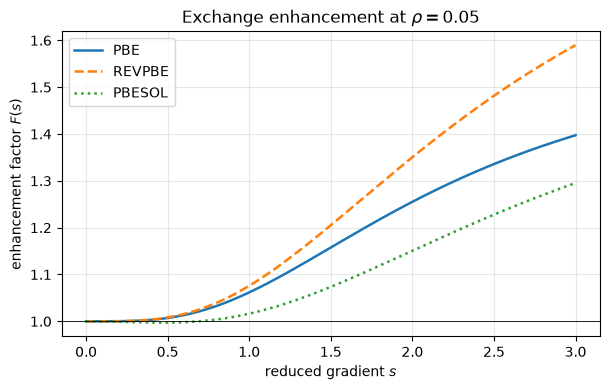

In [2]:
from defumat.xc.functional import get_functional   # no facade route to one functional

rho = 0.05
s = np.linspace(0.0, 3.0, 300)
kf = (3.0 * np.pi**2 * rho) ** (1.0 / 3.0)
sigma = (s * 2.0 * kf * rho) ** 2               # |grad rho|^2 at each s, at fixed rho

fig, ax = plt.subplots(figsize=(6.2, 4.0))
for name, style in (("PBE", "-"), ("REVPBE", "--"), ("PBESOL", ":")):
    functional = get_functional(name)
    gga = np.asarray(functional.gradient_energy(np.full_like(sigma, rho), sigma))
    lda = float(rho * functional.exchange(rho))
    ax.plot(s, 1.0 + gga / lda, style, lw=1.8, label=name)
ax.axhline(1.0, color="k", lw=0.6)
ax.set_xlabel("reduced gradient $s$")
ax.set_ylabel("enhancement factor $F(s)$")
ax.set_title(r"Exchange enhancement at $\rho = %.2f$" % rho)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

$F(0) = 1$ in all three, which is the uniform gas and is not negotiable: a GGA has to
reduce to LDA where the density is flat. Everything above that is the model.

The second potential enters as $-\nabla\cdot(v_2\nabla\rho)$, a divergence, so it integrates
to zero over the cell and moves no charge at all -- it only redistributes it, sharpening the
potential where the density varies fastest. That is exactly where LDA is worst, which is why
a GGA helps most at surfaces, in bonds, and around light atoms.

## Against Quantum ESPRESSO

Three pseudopotential kinds under PBE, then three functionals on the same norm-conserving
cell.

In [3]:
rows = []
for case, label in (("si2-nc-pbe", "PBE, norm-conserving"), ("si2-us-pbe", "PBE, ultrasoft"),
                    ("si2-paw-pbe", "PBE, PAW"), ("si2-nc-revpbe", "revPBE"),
                    ("si2-nc-pbesol", "PBEsol")):
    ours = Calculator.from_file(CASES / f"{case}.in", pseudo_dir=PSEUDO,
                                announce=False).get_scf()
    rows.append((label, ours.total_energy,
                 read_qe_output(CASES / f"reference.out.{case}").total_energy))

print(comparison_table(rows, fmt="{:.9f}",
                       headers=("case", "defumat [Ry]", "pw.x", "difference")))

case                  defumat [Ry]           pw.x  difference
PBE, norm-conserving  -15.727897810  -15.727897810     2.7e-10
PBE, ultrasoft        -22.822566057  -22.822566060     2.7e-09
PBE, PAW              -93.439615230  -93.439615230     1.1e-10
revPBE                -15.734397095  -15.734397090     4.6e-09
PBEsol                -15.696395527  -15.696395530     3.4e-09


The last two rows carry a warning, silenced in the first cell: they run a PBE-generated
dataset under a *different* functional. That is what `input_dft` is for and it is deliberate
here, so that the three functionals are compared on one crystal rather than on three
datasets -- but it is an inconsistency, `pw.x` says so too, and a published number should not
be got this way.

## The bands, and what a gradient correction does not fix

PBE moves silicon's bands by tens of meV against LDA and its gap from 0.49 eV to 0.57 --
still half of the measured 1.17. **The band gap of a Kohn-Sham calculation is not the quantity
experiment measures**, and no gradient correction repairs that; notebook 24 is what does.
What PBE repairs is the energetics, which is why it is what structures, binding energies and
forces are computed with.

largest eigenvalue difference from pw.x   0.052 meV
PBE gap   0.565 eV   (measured 1.17)


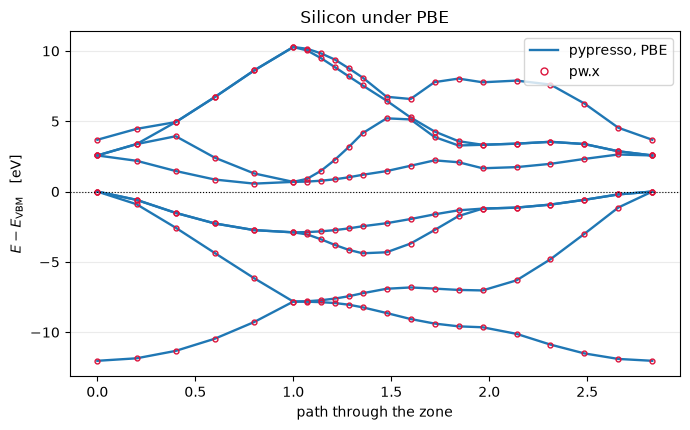

In [4]:
path = Calculator.from_file(CASES / "si2-nc-pbe-bands.in", pseudo_dir=PSEUDO,
                            announce=False).system
bands = pbe.get_bands(kpoints=path.kpoints, nbnd=8)
theirs = read_qe_output(CASES / "reference.out.si2-nc-pbe-bands").eigenvalues[0]
ours = bands.eigenvalues_ev - bands.eigenvalues_ev[:, 3].max()

fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.plot(bands.path_length, ours, "-", color="C0", lw=1.7)
ax.plot(bands.path_length, theirs - theirs[:, 3].max(), "o", color="crimson", ms=3.5,
        mfc="none")
ax.plot([], [], "-", color="C0", lw=1.7, label="defumat, PBE")
ax.plot([], [], "o", color="crimson", ms=5, mfc="none", label="pw.x")
ax.axhline(0.0, color="k", lw=0.8, ls=":")
ax.set_xlabel("path through the zone")
ax.set_ylabel(r"$E - E_{\rm VBM}$   [eV]")
ax.set_title("Silicon under PBE")
ax.legend(loc="upper right")
ax.grid(alpha=0.25, axis="y")
fig.tight_layout()

print("largest eigenvalue difference from pw.x   %.3f meV"
      % (np.abs(bands.eigenvalues_ev - theirs).max() * 1e3))
print("PBE gap   %.3f eV   (measured 1.17)" % bands.gap(8))

## What it refuses

An **unimplemented functional is refused rather than silently replaced by LDA**, which is the
failure mode that matters here: a run that quietly changes the physics and reports success is
worse than one that stops. The three above plus the LDA family are what is in; anything else
a UPF header can name is named back.

---
The tests behind this notebook: `tests/regression/test_gga.py`, which holds the total
energies, their term-by-term breakdown and the eigenvalues on all three kinds of dataset,
and the check that the functional comes from the pseudopotential; and
`tests/unit/test_xc.py`, which holds the potentials against the closed forms `XClib`
derives by hand -- $v_1$ and $v_2$ here are obtained by differentiating the energy, so those
two implementations share nothing and checking one against the other is the test.